# **04 - Unsupervised Clustering**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# Load patient-level data
patient_level = pd.read_parquet("../data/processed/patient_level.parquet")
patient_level.shape, patient_level.head(2)

((128326, 10),
                          patient_id  n_spells  mean_los  pct_emerg  \
 0  TEST000GPDDuWdpt8xc2yxAfCBgqHqZJ         1       0.1        0.0   
 1  TEST001KKuBCtIi3dThnRa3GjJz1PiTc         1       7.5        0.0   
 
    readmit_30d  imd_quintile sex   age ethnicity_group respiratory_group_mode  
 0        False             4   1  64.0      Not stated      Other respiratory  
 1        False          <NA>   1  87.0      Not stated      Other respiratory  )

Approximately 1.8% of records have missing IMD quintile.
The check below shows that none of these patients were readmitted within 30 days. Their exclusion is unlikely to bias modelling results so will remove null IMD quintiles.

In [3]:
# Check missing IMD
missing_imd = patient_level["imd_quintile"].isna()
n_missing = missing_imd.sum()
pct_missing = missing_imd.mean() * 100

# Compare readmission rates for those rows
readmit_missing = patient_level.loc[missing_imd, "readmit_30d"].mean()
readmit_overall = patient_level["readmit_30d"].mean()

print(f"Missing IMD: {n_missing:,} rows ({pct_missing:.2f}%)")
print(f"Readmission rate overall: {readmit_overall:.3%}")
print(f"Readmission rate (missing IMD): {readmit_missing:.3%}")


Missing IMD: 2,255 rows (1.76%)
Readmission rate overall: 2.060%
Readmission rate (missing IMD): 0.000%


In [4]:
# Drop null IMD quintiles
patient_level = patient_level.dropna(subset=["imd_quintile"]).reset_index(drop=True)

In [5]:
# Features for clustering
num_features = ["age", "n_spells", "mean_los", "pct_emerg", "imd_quintile"]
cat_features = ["sex", "ethnicity_group", "respiratory_group_mode"]  # optional for clustering

features = num_features + cat_features
X_df = patient_level[features].copy()

In [ ]:
X_df.head()

,age,n_spells,mean_los,pct_emerg,imd_quintile,sex,ethnicity_group,respiratory_group_mode
0,64.0,1,0.100,0.0,4,1,Not stated,Other respiratory
1,51.0,1,2.000,0.0,5,2,White,Pneumonia
2,69.0,1,2.700,0.0,5,1,Asian or Asian British,Other respiratory
3,77.0,1,1.100,0.0,2,2,Other Ethnic Groups,Pneumonia
4,49.0,4,7.175,0.5,2,1,White,Other respiratory


In [6]:
# Preprocess (scale numeric, one-hot encode categorical)
numeric = Pipeline([("scaler", StandardScaler())])
categorical = Pipeline([("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

prep = ColumnTransformer([
    ("num", numeric, num_features),
    ("cat", categorical, cat_features)
], remainder="drop")

X = prep.fit_transform(X_df)
feature_names = (list(num_features) + 
                 list(prep.named_transformers_["cat"].named_steps["oh"].get_feature_names_out(cat_features)))

In [ ]:
# Determine number of clusters with help of elbow method and silhouette score
ks = range(2, 9)
inertia = []
sil = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))

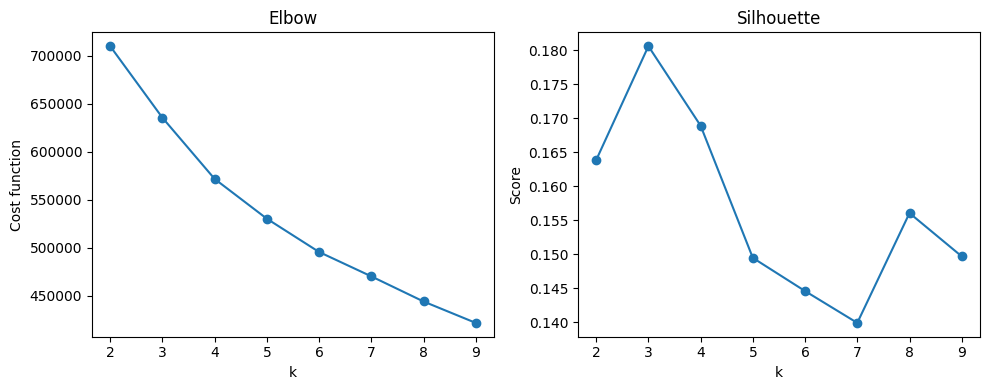

In [ ]:
# Plot results
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(ks, inertia, marker="o"); ax[0].set_title("Elbow"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Cost function")
ax[1].plot(ks, sil, marker="o"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Score")
plt.tight_layout(); plt.show()

A silhouette score of 0.18 indicates that samples are on or very close to the decision boundary between neighboring clusters.

In [7]:
# Choose k (either 3 or 4 according to plots). Silhouette score is higher for k=3
best_k = 3

# Fit final k-means
kmeans = KMeans(n_clusters=best_k, n_init=50, random_state=42)
patient_level["cluster"] = kmeans.fit_predict(X)
patient_level["cluster"] = patient_level["cluster"].astype("category")

# Quick check
patient_level["cluster"].value_counts().sort_index()

cluster
0    11644
1    61446
2    52981
Name: count, dtype: int64

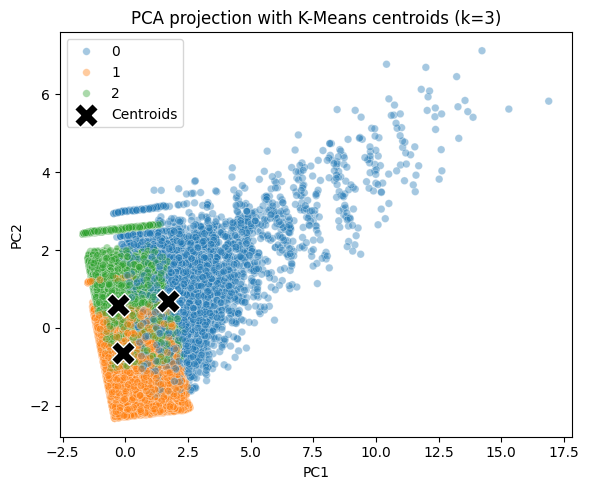

In [ ]:
# Visualise clusters in 2D (PCA)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
pc = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pc["cluster"] = patient_level["cluster"].values

# Compute cluster centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=pc, x="PC1", y="PC2",
    hue="cluster", palette="tab10",
    alpha=0.4, s=30
)

# Add centroids
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s=300, c="black", marker="X", edgecolor="white", linewidth=1.0,
    label="Centroids"
)

plt.title("PCA projection with K-Means centroids (k=3)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Cluster profiling personas

profile_cols = ["age","n_spells","mean_los","pct_emerg","imd_quintile",
                "sex","ethnicity_group","respiratory_group_mode","readmit_30d"]
prof = (patient_level[profile_cols + ["cluster"]]
        .groupby("cluster")
        .agg(
            n=("age","size"),
            age_median=("age","median"),
            n_spells_median=("n_spells","median"),
            mean_los_median=("mean_los","median"),
            pct_emerg_mean=("pct_emerg","mean"),
            imd_median=("imd_quintile","median"),
            readmit_rate=("readmit_30d","mean")
        )
        .reset_index())
display(prof)

# Top categories per cluster
top_cats = {}
for c in ["sex","ethnicity_group","respiratory_group_mode"]:
    top = (patient_level.groupby(["cluster", c]).size()
             .groupby(level=0)
             .apply(lambda s: (s/s.sum()).sort_values(ascending=False).head(2)))
    top_cats[c] = top

top_cats  # quickly inspect in notebook


C:\Users\khize\AppData\Local\Temp\ipykernel_22304\255203221.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cluster")


,cluster,n,age_median,n_spells_median,mean_los_median,pct_emerg_mean,imd_median,readmit_rate
0,0,11644,57.416667,2.0,8.8,0.455724,3.0,0.226984
1,1,61446,57.0,1.0,5.0,0.000000,3.0,0.000000
2,2,52981,58.0,1.0,5.0,1.000000,3.0,0.000000


C:\Users\khize\AppData\Local\Temp\ipykernel_22304\255203221.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top = (patient_level.groupby(["cluster", c]).size()
C:\Users\khize\AppData\Local\Temp\ipykernel_22304\255203221.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(level=0)
C:\Users\khize\AppData\Local\Temp\ipykernel_22304\255203221.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top = (patient_

{'sex': cluster  cluster  sex
 0        0        2      0.565098
                   1      0.434902
 1        1        2      0.557774
                   1      0.442226
 2        2        2      0.554085
                   1      0.445915
 dtype: float64,
 'ethnicity_group': cluster  cluster  ethnicity_group
 0        0        White              0.735572
                   Not stated         0.092150
 1        1        White              0.731390
                   Not stated         0.097045
 2        2        White              0.732546
                   Not stated         0.096299
 dtype: float64,
 'respiratory_group_mode': cluster  cluster  respiratory_group_mode
 0        0        Other respiratory         0.501975
                   COPD                      0.232910
 1        1        Other respiratory         0.454025
                   Pneumonia                 0.326677
 2        2        Other respiratory         0.448897
                   Pneumonia                 0.33200

In [9]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X_use = X  # your scaled numeric matrix used for k-means
labels = kmeans.labels_  # for k=3

print("Silhouette:", silhouette_score(X_use, labels, sample_size=10000, random_state=42))
print("Calinski–Harabasz:", calinski_harabasz_score(X_use, labels))
print("Davies–Bouldin:", davies_bouldin_score(X_use, labels))


Silhouette: 0.18118468374284136
Calinski–Harabasz: 19548.14388295304
Davies–Bouldin: 1.9114081751084273


In [10]:
import numpy as np
from sklearn.metrics import silhouette_samples
samp = silhouette_samples(X_use, labels)
pd.DataFrame({"cluster": labels, "s": samp}).groupby("cluster")["s"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,11644.0,0.081364,0.103169,-0.060867,-0.009358,0.064371,0.102985,0.321333
1,61446.0,0.190624,0.031123,0.078612,0.170767,0.192512,0.212515,0.264780
2,52981.0,0.190756,0.031267,0.081581,0.170582,0.192567,0.212870,0.263621


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def fit_labels(seed): 
    return KMeans(n_clusters=3, n_init=20, random_state=seed).fit_predict(X_use)

L1 = fit_labels(42)
L2 = fit_labels(123)
L3 = fit_labels(999)

print("ARI 42 vs 123:", adjusted_rand_score(L1, L2))
print("ARI 42 vs 999:", adjusted_rand_score(L1, L3))


ARI 42 vs 123: 1.0
ARI 42 vs 999: 1.0


In [12]:
bins = [0, 18, 40, 60, 80, np.inf]
labels = ["Child", "Young adult", "Middle-aged", "Older adult", "80+"]
patient_level["age_band"] = pd.cut(patient_level["age"], bins=bins, labels=labels, right=False)

In [13]:
# A) current: numeric-only features
num_A = ["age","n_spells","mean_los","pct_emerg","imd_quintile"]
XA = StandardScaler().fit_transform(patient_level[num_A].dropna())

lab_A = KMeans(n_clusters=3, n_init=20, random_state=42).fit_predict(XA)

# B) add quinary age bands as one-hot
age_band = pd.cut(patient_level["age"], bins=list(range(0,95,5))+[10**6], right=False)
OH = pd.get_dummies(age_band, prefix="ageband", dummy_na=False)

XB = np.c_[XA, OH.loc[patient_level[num_A].dropna().index].to_numpy()]  # align rows
lab_B = KMeans(n_clusters=3, n_init=20, random_state=42).fit_predict(XB)

print("ARI (continuous-age vs age-bands):", adjusted_rand_score(lab_A, lab_B))

ARI (continuous-age vs age-bands): 0.8563528796877488


In [14]:
# After creating patient_level["age_band"]
OH_quinary = pd.get_dummies(pd.cut(patient_level["age"], bins=list(range(0,95,5))+[10**6]), prefix="age5", dummy_na=False)
OH_broad = pd.get_dummies(patient_level["age_band"], prefix="ageband", dummy_na=False)

XB_quinary = np.c_[XA, OH_quinary.loc[patient_level[num_A].dropna().index]]
XB_broad = np.c_[XA, OH_broad.loc[patient_level[num_A].dropna().index]]

lab_quinary = KMeans(n_clusters=3, n_init=20, random_state=42).fit_predict(XB_quinary)
lab_broad = KMeans(n_clusters=3, n_init=20, random_state=42).fit_predict(XB_broad)

print("ARI (quinary vs continuous):", adjusted_rand_score(lab_A, lab_quinary))
print("ARI (broad vs continuous):", adjusted_rand_score(lab_A, lab_broad))


ARI (quinary vs continuous): 0.8563528796877488
ARI (broad vs continuous): 0.4724391031292623


In [17]:
# Use continuous age for clustering
# Then describe each cluster post hoc:
pd.cut(patient_level["age"], bins=[0,18,40,60,80,np.inf],
       labels=["Child","Young adult","Middle-aged","Older adult","80+"]
).value_counts(normalize=True)

age
Older adult    0.300450
Middle-aged    0.233265
Young adult    0.226341
80+            0.157863
Child          0.082081
Name: proportion, dtype: float64

In [18]:
# assuming patient_level['cluster'] and patient_level['age_band'] exist
ct = (
    pd.crosstab(patient_level['cluster'], patient_level['age_band'], normalize='index')
    .round(3)
)

print(ct)

age_band  Child  Young adult  Middle-aged  Older adult    80+
cluster                                                      
0         0.078        0.223        0.229        0.304  0.166
1         0.077        0.224        0.228        0.302  0.170
2         0.077        0.218        0.231        0.301  0.173


In [24]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=feature_names)

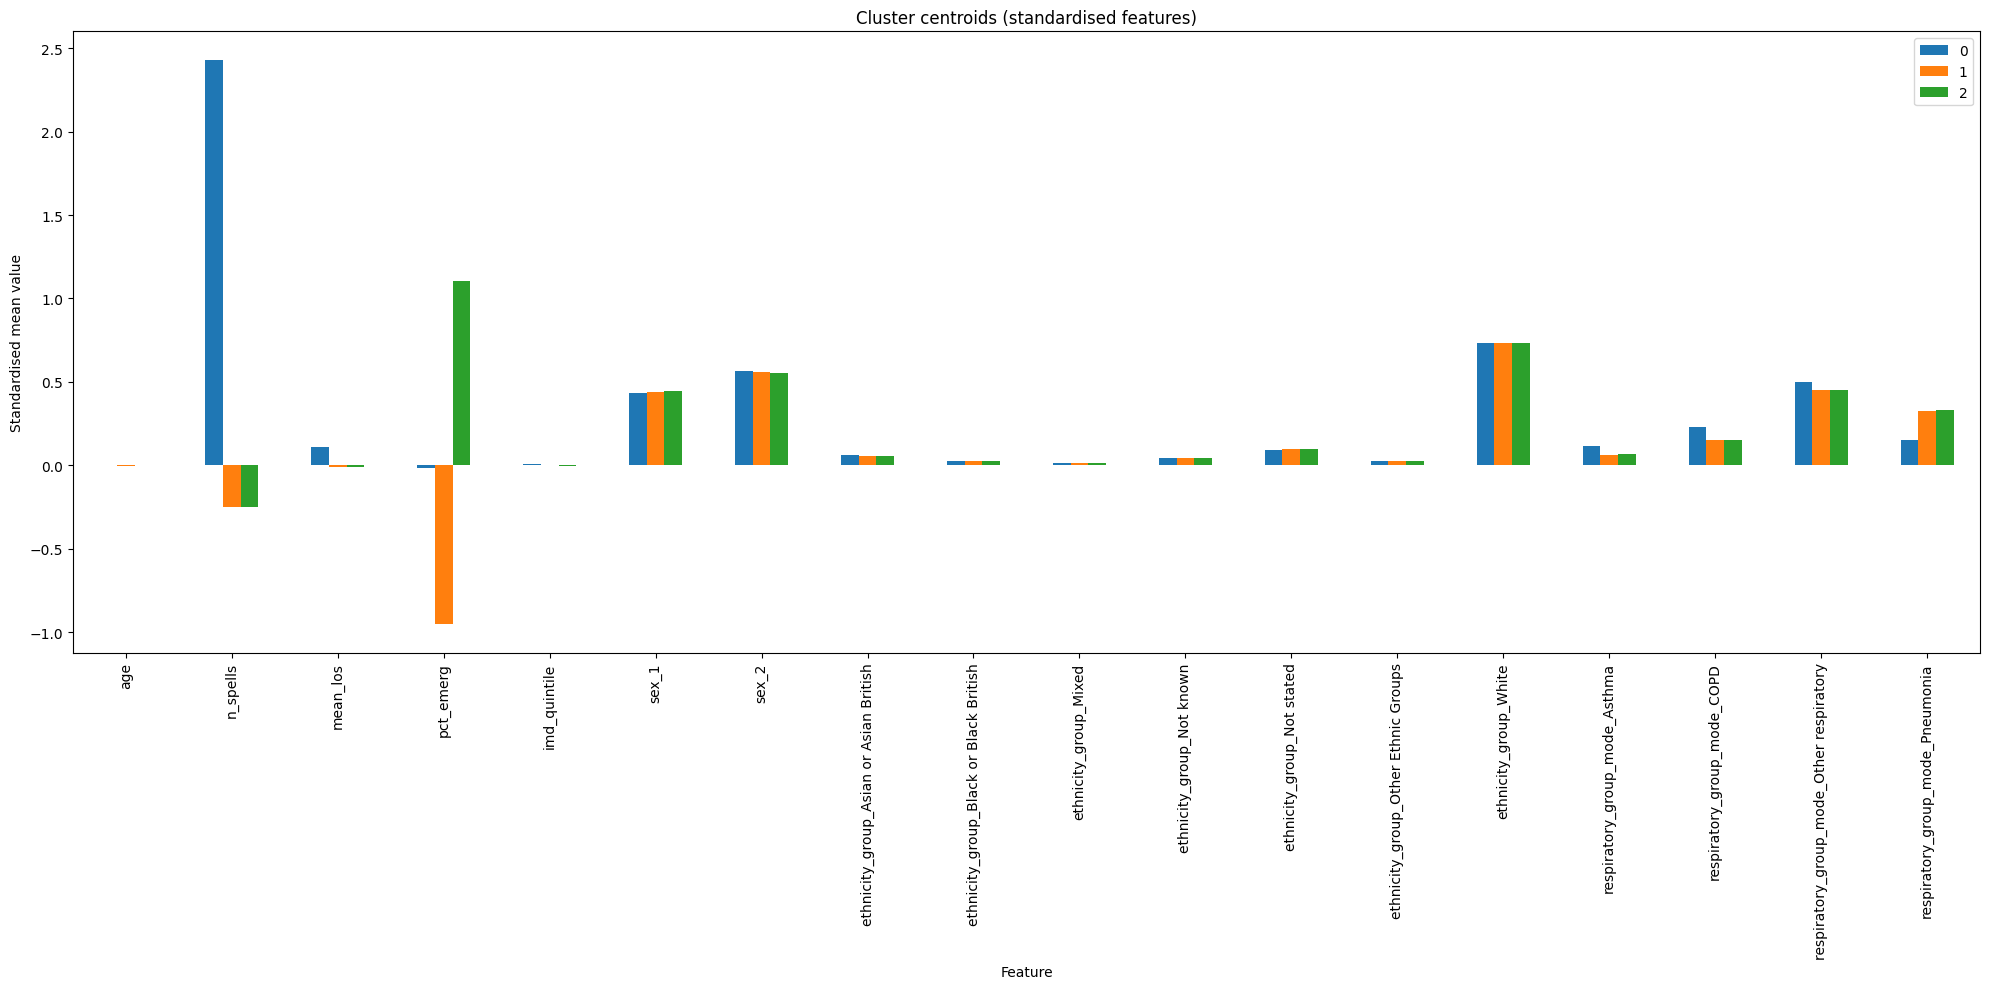

In [27]:
# Plot
centroids.T.plot(kind="bar", figsize=(20,10))
plt.title("Cluster centroids (standardised features)")
plt.ylabel("Standardised mean value")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()
